In [37]:
!pip install "CHAID[graph]"
!pip install graphviz

In [38]:
# Import libraries
import pandas as pd
import statsmodels.api as sm
from CHAID import Tree

In [39]:
# Import data
data = sm.datasets.get_rdataset("ResumeNames",
                                package = "AER").data
data.head()

,name,gender,ethnicity,quality,call,city,jobs,experience,honors,volunteer,...,minimum,equal,wanted,requirements,reqexp,reqcomm,reqeduc,reqcomp,reqorg,industry
0,Allison,female,cauc,low,no,chicago,2,6,no,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
1,Kristen,female,cauc,high,no,chicago,3,6,no,yes,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
2,Lakisha,female,afam,low,no,chicago,1,6,no,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
3,Latonya,female,afam,high,no,chicago,4,6,no,yes,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
4,Carrie,female,cauc,high,no,chicago,3,22,no,no,...,some,yes,secretary,yes,yes,no,no,yes,yes,health/education/social services


In [40]:
# Remove name variable
data = data.iloc[:,1:]
data.head()

,gender,ethnicity,quality,call,city,jobs,experience,honors,volunteer,military,...,minimum,equal,wanted,requirements,reqexp,reqcomm,reqeduc,reqcomp,reqorg,industry
0,female,cauc,low,no,chicago,2,6,no,no,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
1,female,cauc,high,no,chicago,3,6,no,yes,yes,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
2,female,afam,low,no,chicago,1,6,no,no,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
3,female,afam,high,no,chicago,4,6,no,yes,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
4,female,cauc,high,no,chicago,3,22,no,no,no,...,some,yes,secretary,yes,yes,no,no,yes,yes,health/education/social services


In [41]:
# Find unique values
data.apply(pd.Series.nunique)

gender           2
ethnicity        2
quality          2
call             2
city             2
jobs             7
experience      26
honors           2
volunteer        2
military         2
holes            2
school           2
email            2
computer         2
special          2
college          2
minimum         13
equal            2
wanted           6
requirements     2
reqexp           2
reqcomm          2
reqeduc          2
reqcomp          2
reqorg           2
industry         7
dtype: int64

In [42]:
data.dtypes

gender          object
ethnicity       object
quality         object
call            object
city            object
jobs             int64
experience       int64
honors          object
volunteer       object
military        object
holes           object
school          object
email           object
computer        object
special         object
college         object
minimum         object
equal           object
wanted          object
requirements    object
reqexp          object
reqcomm         object
reqeduc         object
reqcomp         object
reqorg          object
industry        object
dtype: object

<Axes: xlabel='jobs', ylabel='Density'>

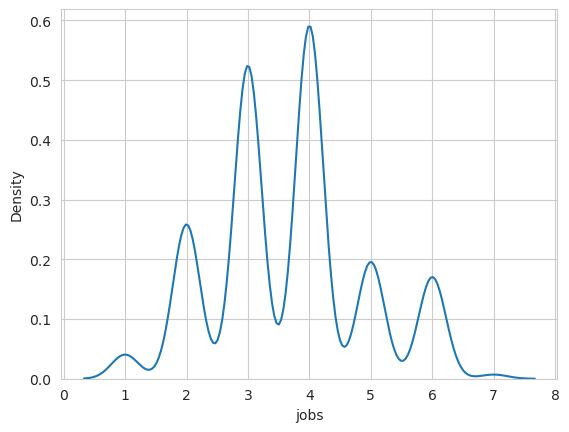

In [43]:
# Visualize jobs variable
import seaborn as sns
sns.set_style('whitegrid')
sns.kdeplot(data.jobs)

In [44]:
# Transform jobs variable
data.jobs = pd.cut(x = data.jobs,
                   bins = [-1, 2.9,4.9,9],
                   labels = [0,1,2])
data.jobs

0       0
1       1
2       0
3       1
4       1
       ..
4865    0
4866    1
4867    2
4868    1
4869    1
Name: jobs, Length: 4870, dtype: category
Categories (3, int64): [0 < 1 < 2]

In [45]:
data.jobs = pd.factorize(data.jobs)[0]
data.jobs

0       0
1       1
2       0
3       1
4       1
       ..
4865    0
4866    1
4867    2
4868    1
4869    1
Name: jobs, Length: 4870, dtype: int64

<Axes: xlabel='experience', ylabel='Density'>

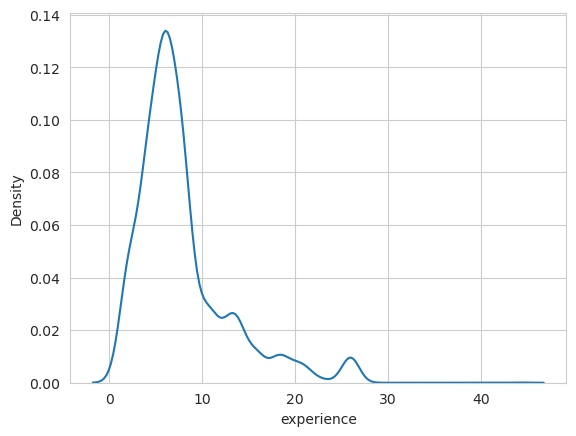

In [46]:
# Visualize experience variable
sns.set_style('whitegrid')
sns.kdeplot(data.experience)

In [47]:
# Transform experience variable
data.experience = pd.qcut(x = data.experience,
                   q = 3,
                   labels = [0,1,2])
data.experience = pd.factorize(data.experience)[0]
data.experience

0       0
1       0
2       0
3       0
4       1
       ..
4865    2
4866    0
4867    0
4868    2
4869    0
Name: experience, Length: 4870, dtype: int64

In [48]:
# Minimum variable
data.minimum.value_counts()

minimum
none    2746
some    1064
2        356
3        331
5        163
1        142
10        18
7         12
8         10
0.5        8
4          8
6          8
0          4
Name: count, dtype: int64

In [49]:
# Transform minimum variable
replacement_dictionary = {'none': 0,
                          '0': 0,
                          '0.5': 0,
                          '1': 1,
                          '2': 1,
                          'some': 2,
                          '3': 2,
                          '4': 2,
                          '5': 3,
                          '6': 3,
                          '7': 3,
                          '8': 3,
                          '10': 3}
data['minimum'] = data['minimum'].replace(replacement_dictionary)
data.minimum

/tmp/ipykernel_2006815/416592776.py:15: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



0       3
1       3
2       3
3       3
4       2
       ..
4865    0
4866    0
4867    0
4868    0
4869    0
Name: minimum, Length: 4870, dtype: int64

In [50]:
# Transforming remaining variables
data = pd.get_dummies(data, drop_first = True)
data.head()

,jobs,experience,minimum,gender_male,ethnicity_cauc,quality_low,call_yes,city_chicago,honors_yes,volunteer_yes,...,reqcomm_yes,reqeduc_yes,reqcomp_yes,reqorg_yes,industry_finance/insurance/real estate,industry_health/education/social services,industry_manufacturing,industry_trade,industry_transport/communication,industry_unknown
0,0,0,3,False,True,True,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
1,1,0,3,False,True,False,False,True,False,True,...,False,False,True,False,False,False,True,False,False,False
2,0,0,3,False,False,True,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
3,1,0,3,False,False,False,False,True,False,True,...,False,False,True,False,False,False,True,False,False,False
4,1,1,2,False,True,False,False,True,False,False,...,False,False,True,True,False,True,False,False,False,False


# CHAID

In [51]:
# Get y name
y_name = data.call_yes.name
y_name

'call_yes'

In [52]:
# Get IV names
X_names = data.drop(columns = 'call_yes').columns
print(X_names)
print(len(X_names))

Index(['jobs', 'experience', 'minimum', 'gender_male', 'ethnicity_cauc',
       'quality_low', 'city_chicago', 'honors_yes', 'volunteer_yes',
       'military_yes', 'holes_yes', 'school_yes', 'email_yes', 'computer_yes',
       'special_yes', 'college_yes', 'equal_yes', 'wanted_office support',
       'wanted_other', 'wanted_retail sales', 'wanted_secretary',
       'wanted_supervisor', 'requirements_yes', 'reqexp_yes', 'reqcomm_yes',
       'reqeduc_yes', 'reqcomp_yes', 'reqorg_yes',
       'industry_finance/insurance/real estate',
       'industry_health/education/social services', 'industry_manufacturing',
       'industry_trade', 'industry_transport/communication',
       'industry_unknown'],
      dtype='object')
34


In [53]:
# CHAID tree
model = Tree.from_pandas_df(data,
                            dict(zip(X_names,
                                     ['ordinal']*3 + ['nominal'] * 31)),
                            y_name,
                            max_depth = 3,
                            min_child_node_size = 250)
print(model)

[([], {False: 4478.0, True: 392.0}, (special_yes, p=9.09108860261878e-15, score=60.08363933760746, groups=[[False], [True]]), dof=1)), ([False], {False: 3075.0, True: 194.0}, (requirements_yes, p=0.0002718068476768014, score=13.25532368278205, groups=[[False], [True]]), dof=1)), ([False], {False: 576.0, True: 57.0}, (experience, p=0.003975225728095155, score=8.295096983690131, groups=[[0], [1, 2]]), dof=1)), ([0], {False: 346.0, True: 23.0}, <Invalid Chaid Split> - the max depth has been reached), ([1, 2], {False: 230.0, True: 34.0}, <Invalid Chaid Split> - the max depth has been reached), ([True], {False: 2499.0, True: 137.0}, (ethnicity_cauc, p=0.03903799830275106, score=4.2592132081738185, groups=[[False], [True]]), dof=1)), ([False], {False: 1266.0, True: 57.0}, <Invalid Chaid Split> - the max depth has been reached), ([True], {False: 1233.0, True: 80.0}, <Invalid Chaid Split> - the max depth has been reached), ([True], {False: 1403.0, True: 198.0}, (city_chicago, p=0.0003119135961

In [54]:
!pip install networkx

    node_id  parent_id  depth  is_terminal choice_from_parent       n  \
0         0        NaN      0        False                 []  4870.0   
1         1        0.0      1        False            [False]  3269.0   
2         2        1.0      2        False            [False]   633.0   
3         3        2.0      3         True                [0]   369.0   
4         4        2.0      3         True             [1, 2]   264.0   
5         5        1.0      2        False             [True]  2636.0   
6         6        5.0      3         True            [False]  1323.0   
7         7        5.0      3         True             [True]  1313.0   
8         8        0.0      1        False             [True]  1601.0   
9         9        8.0      2        False            [False]   660.0   
10       10        9.0      3         True            [False]   372.0   
11       11        9.0      3         True             [True]   288.0   
12       12        8.0      2        False         

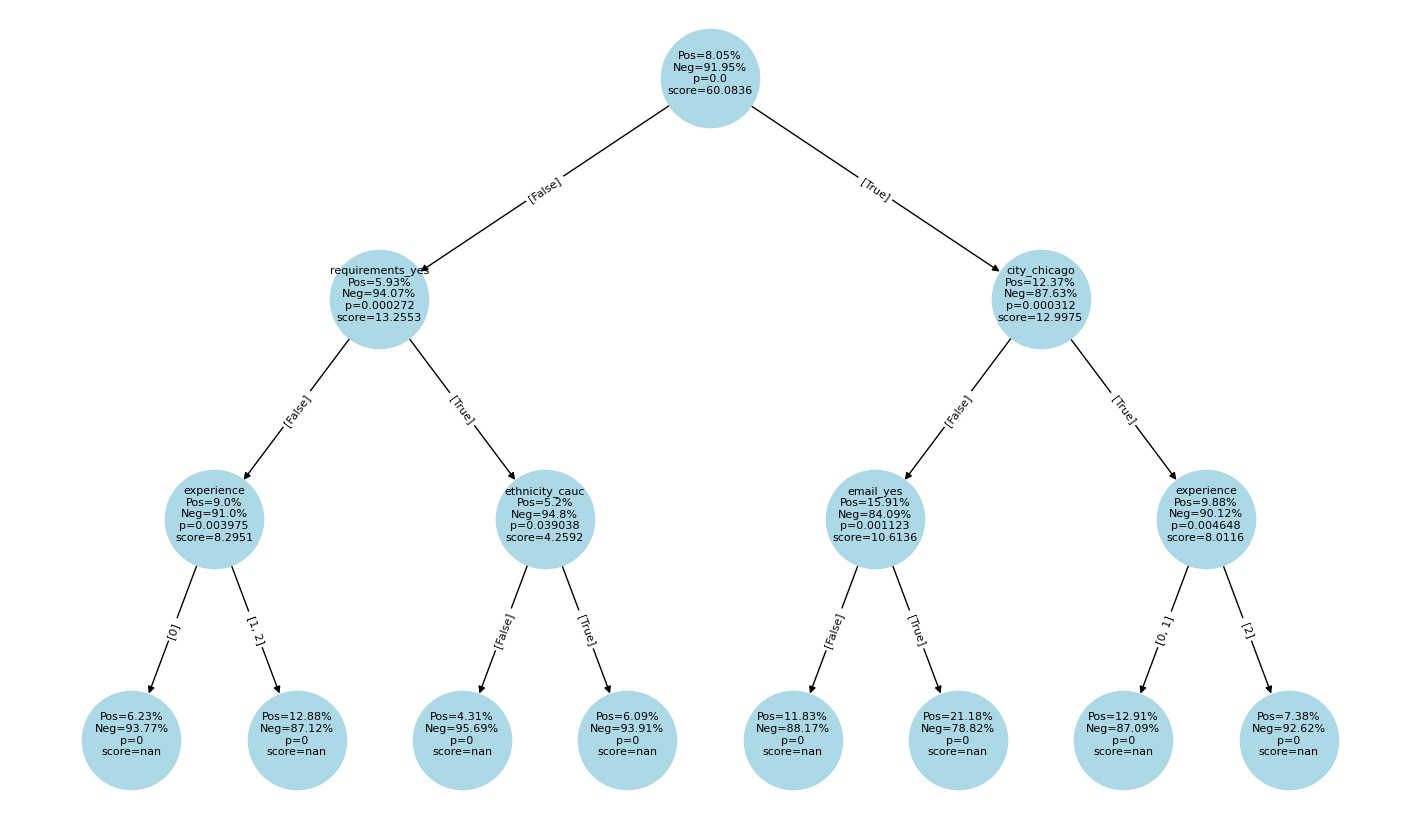

In [55]:
import pandas as pd
import numpy as np # if using numpy
 
def chaid_tree_to_df(tree):
    # Materialize nodes and index by id
    nodes = list(tree)
    by_id = {n.node_id: n for n in nodes}
 
    def depth(n):
        d = 0
        p = n.parent
        while p is not None:
            d += 1
            p = by_id[p].parent
        return d
 
    rows = []
    for n in nodes:
        counts = getattr(n, "members", None)
        # safe majority (works whether keys are ints/bools/strings)
        majority = None
        total_n = None
        if isinstance(counts, dict) and counts:
            majority = max(counts, key=counts.get)
            total_n = sum(counts.values())
 
        # split variable name is stored on the *parent* that created this node
        split_var = None
        if n.parent is not None:
            split_var = getattr(by_id[n.parent], "split_variable", None)
            split_var = getattr(by_id[n.node_id], "split_variable", None)
 
        rows.append({
            "node_id": n.node_id,
            "parent_id": n.parent,
            "depth": depth(n),
            "is_terminal": n.is_terminal,
            "choice_from_parent": n.choices,   # e.g. [False], [0,1], etc.
            "n": total_n,
            "counts": counts,
            "majority_class": majority,
            "split_variable_from_parent": split_var,  # variable used to create THIS node
            "p": n.p,
            "score": n.score,
        })
 
    df = pd.DataFrame(rows).sort_values("node_id").reset_index(drop=True)
 
    # expand class counts into columns
    all_classes = set()
    for d in df["counts"].dropna():
        all_classes.update(d.keys())
    for cls in sorted(all_classes, key=lambda x: str(x)):
        df[f"class_{cls}_count"] = df["counts"].apply(
            lambda d: (d.get(cls, 0) if isinstance(d, dict) else 0)
        )
 
    return df
 
# --- use it on your existing model ---
# (your tree is already built by iterating, but this is fine either way)
# tree = model  # if your variable is `model`; otherwise use your Tree object
df_tree = chaid_tree_to_df(model)
df_tree
 
## for Plot
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
 
# Recursive layout for hierarchy (no pygraphviz needed)
def hierarchy_pos(G, root=None, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, parent=None):
    if pos is None:
        pos = {}
    children = list(G.neighbors(root))
    if not isinstance(G, nx.DiGraph):
        raise TypeError("G must be a DiGraph")
    if parent is not None:
        children = [c for c in children if c != parent]
    if len(children) != 0:
        dx = width / len(children)
        nextx = xcenter - width / 2 - dx / 2
        for child in children:
            nextx += dx
            pos = hierarchy_pos(G, root=child, width=dx, vert_gap=vert_gap,
                                vert_loc=vert_loc - vert_gap, xcenter=nextx, pos=pos, parent=root)
    pos[root] = (xcenter, vert_loc)
    return pos
 
 
def plot_clean_tree(df_tree):
    G = nx.DiGraph()
 
    # Add nodes with labels
    for _, row in df_tree.iterrows():
        label = "" #f"Node {int(row['node_id'])}\n"
        if row['split_variable_from_parent']:
            label += f"{row['split_variable_from_parent']}\n"            
        t = row['class_False_count'] + row['class_True_count']
        tT = row['class_True_count'] / t * 100
        tF = row['class_False_count'] / t * 100
 
        label += f"Pos={round(tT, 2)}%\n"
        label += f"Neg={round(tF,2)}%\n"
        if np.isnan(row['p'])  :
            p=0
        else : 
            p=row['p']
        label += f"p={round(p,6)}\n"
        label += f"score={round(row['score'],4)}\n"
        #label += f"Majority: {row['majority_class']}"
        
 
        G.add_node(int(row['node_id']), label=label)
        
        if not pd.isna(row['parent_id']):
            edge_label = f"{row['choice_from_parent']}"
            G.add_edge(int(row['parent_id']), int(row['node_id']), label=edge_label)
 
    # Hierarchical layout (our custom function)
    pos = hierarchy_pos(G, root=0)
 
    plt.figure(figsize=(14, 8))
    nx.draw(G, pos,
            labels=nx.get_node_attributes(G, 'label'),
            node_size=5000, node_color="lightblue",
            font_size=8, #font_weight="bold",
            arrows=True)
 
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
 
    plt.axis("off")
    plt.show()
 
print(df_tree)
plot_clean_tree(df_tree)